In [ ]:
# start что делать:
#  1. загрузить фото 
#  2. читение файла Используйте PIL.Image.open() или matplotlib.image.imread()
#  3. преобразование в массиве numpy.ndarray
#  4. преобразить в серый цвет: .convert('L')

# svd потом:
# 5. применять функция : np.linalg.svd(матрица, full_matrices=False)
# 6. использовать формулу и аппроксимировать потом восстоновить 

# потоказать результаты 
# сначало сжатое изображение потом изначальное

# проверка 


# U and V change the point of view so that we can see the data clearly in an elipse
# why elipse? its characters are the singular values. in R2 we have a 2x2 so our singuar values describe the width and height of this elipse 
# by multipling AtA the eignenvalues of this new matrix will be our V matrix and th eignenvalues will be our singular values. 

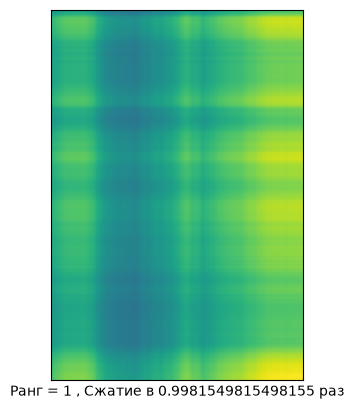

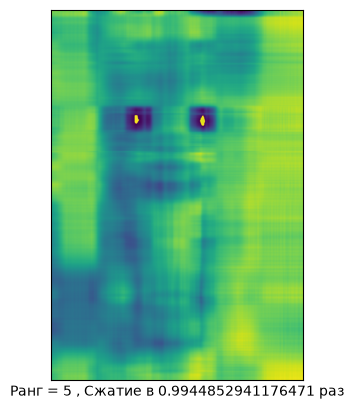

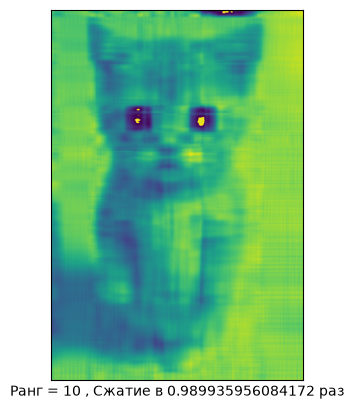

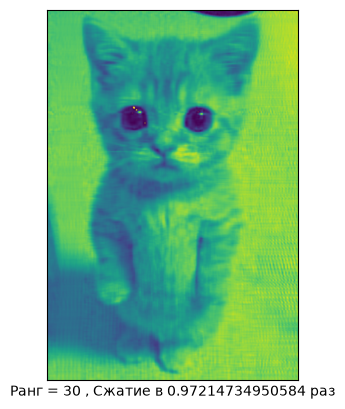

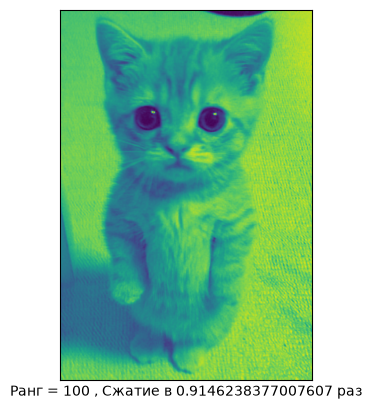

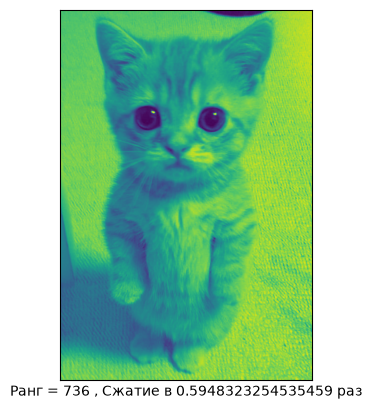

✅ Все автоматические проверки пройдены. Задание выполнено корректно!


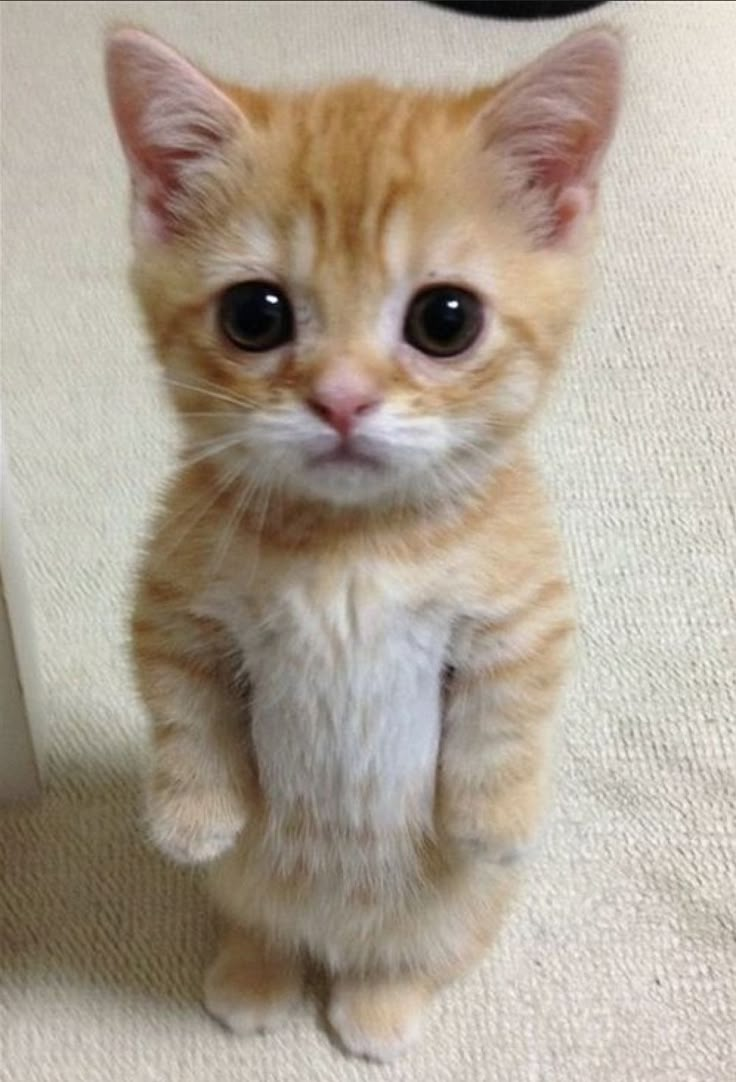

In [50]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from sklearn.metrics import mean_squared_error

# Чтение

#  1. загрузить фото 
#  2. читение файла Используйте PIL.Image.open() или matplotlib.image.imread()
#  3. преобразование в массиве numpy.ndarray
#  4. преобразить в серый цвет: .convert('L')

img = Image.open('my_pic.jpg')
img_gray = img.convert('L')  # Серый
img_array = np.array(img_gray) # или np.array(img) для RGB

# SVD 
# this function gives me the done U sigma and Vt matrixes so that i dont have to find the eignenvectors (for U and V) and eignenvaleus for Sigma  yayyyy
U, s, Vt = np.linalg.svd(img_array, full_matrices=False)



rk = [1, 5, 10, 30, 100, min(len(img_array), len(img_array[1]))]

# Восстановление для ранга r

approximations = []

for r in rk:
    U_r = U[:, :r]
    S_r = np.diag(s[:r])
    Vt_r = Vt[:r, :]
    reconstructed = U_r @ S_r @ Vt_r
    approximations.append(reconstructed)
    
    # calulating the approximation x = original elements / compressed elements 
    m = len(U_r)
    n = len(Vt_r)
    compressed_el = r*(m+n+1)
    original_el = m*n
    x = original_el / compressed_el

    # visualizing 
    plt.clf()
    plt.imshow(reconstructed, cmap='gray') # для серого
    plt.imshow(reconstructed.astype(np.uint8)) # для RGB (привести к целым)
    plt.xlabel(f'Ранг = {r} , Сжатие в {x} раз')
    plt.xticks([])  # removes horizontal pixel markers
    plt.yticks([])
    plt.show()
    plt.close()




# ---------- БЛОК АВТОПРОВЕРКИ (НЕ РЕДАКТИРОВАТЬ) ----------
# Предполагается, что у вас есть переменные:
# original_shape = (h, w, c) или (h, w)
# list_of_ranks = [1, 5, 10, 30, 100, ...]
# approximations = список восстановленных массивов (numpy) для каждого ранга

original_shape = (len(img_array), len(img_array[0]))
list_of_ranks = [1, 5, 10, 30, 100, min(len(img_array), len(img_array[1]))]


# 1. Проверка размерностей
for i, r in enumerate(list_of_ranks):
    assert approximations[i].shape == original_shape, f"Ошибка: размерность для ранга {r} не совпадает с исходной"

# 2. Проверка, что значения не выходят за пределы 0-255 (для RGB/серого)
for i, r in enumerate(list_of_ranks):
    arr = approximations[i]
    if arr.dtype != np.uint8:
        arr = np.clip(arr, 0, 255) # Если float, то проверяем диапазон
    assert arr.max() <= 255.1, f"Значения превышают 255 для ранга {r}"
    assert arr.min() >= -0.1, f"Значения меньше 0 для ранга {r}"

# 3. Проверка, что с ростом ранга ошибка уменьшается (метрика MSE)
from sklearn.metrics import mean_squared_error
mse_list = []
original_flat = img_array.flatten()

for i in range(len(approximations)):
    # Если цветная, считаем MSE по всем каналам
    mse = mean_squared_error(original_flat, approximations[i].flatten())
    mse_list.append(mse)

# Проверяем монотонность (MSE должен падать, так как мы добавляем сингулярные числа)
for i in range(1, len(mse_list)):
    assert mse_list[i] <= mse_list[i-1] + 1e-6, f"MSE не уменьшается между рангами {list_of_ranks[i-1]} и {list_of_ranks[i]}"

print("✅ Все автоматические проверки пройдены. Задание выполнено корректно!")


img
